We will use kmeans clustering to figure out the species of the penguins

In [1]:
# standard packaging

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(color_codes=True, rc={'figure.figsize':(10,8)})



In [2]:
# load the dataset from GitHub - original source

penguins = pd.read_csv("https://github.com/allisonhorst/palmerpenguins/raw/5b5891f01b52ae26ad8cb9755ec93672f49328a8/data/penguins_size.csv")

Data prep

In [3]:
penguins_clean = penguins.dropna(how = "any")
penguins_clean.info()
penguins_clean.reset_index(inplace=True, drop = True)
penguins_clean.head()

<class 'pandas.core.frame.DataFrame'>
Index: 334 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species_short      334 non-null    object 
 1   island             334 non-null    object 
 2   culmen_length_mm   334 non-null    float64
 3   culmen_depth_mm    334 non-null    float64
 4   flipper_length_mm  334 non-null    float64
 5   body_mass_g        334 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 20.9+ KB


,species_short,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE


Encode the variables

In [4]:
#encoding categorical variables
y = penguins_clean["species_short"]
penguins_x = penguins_clean.iloc[:,1:]
X = pd.get_dummies(penguins_x)
X.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,island_Biscoe,island_Dream,island_Torgersen,sex_.,sex_FEMALE,sex_MALE
0,39.1,18.7,181.0,3750.0,False,False,True,False,False,True
1,39.5,17.4,186.0,3800.0,False,False,True,False,True,False
2,40.3,18.0,195.0,3250.0,False,False,True,False,True,False
3,36.7,19.3,193.0,3450.0,False,False,True,False,True,False
4,39.3,20.6,190.0,3650.0,False,False,True,False,False,True


Training attempt

In [6]:
from sklearn.cluster import KMeans

model = KMeans(n_clusters=3)
model.fit(X)

KMeans(n_clusters=3)

In [7]:
# Using the predict method of KMeans to predict 3 clusters using the sample data

labels = model.predict(X)

In [8]:
# We plot a cross tab matrix to check how well has our K-Means model classified the Species

matrix = pd.DataFrame({'labels': labels, 'species': y})
ct = pd.crosstab(matrix['labels'], matrix['species'])
print(ct)

species  Adelie  Chinstrap  Gentoo
labels                            
0             0          0      70
1           108         52       1
2            38         16      49


Now standard scaling ?


In [9]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [10]:
X_scaled = scaler.fit_transform(X)

In [11]:
#Train another model
model_2 = KMeans(n_clusters=3)
model_2.fit(X_scaled)

KMeans(n_clusters=3)

In [12]:
labels_ss = model_2.predict(X_scaled)

In [13]:
#plotting the Cross-tab matrix with the new labels

matrix_new = pd.DataFrame({'labels': labels_ss, 'species': y})
ct_new = pd.crosstab(matrix_new['labels'], matrix_new['species'])
print(ct_new)

species  Adelie  Chinstrap  Gentoo
labels                            
0            73         34       0
1             0          0     120
2            73         34       0


In [14]:
penguins_clean["kmeansLabels"] = labels_ss

/tmp/ipykernel_11579/780154921.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  penguins_clean["kmeansLabels"] = labels_ss


See where the problem is

<Axes: xlabel='culmen_length_mm', ylabel='culmen_depth_mm'>

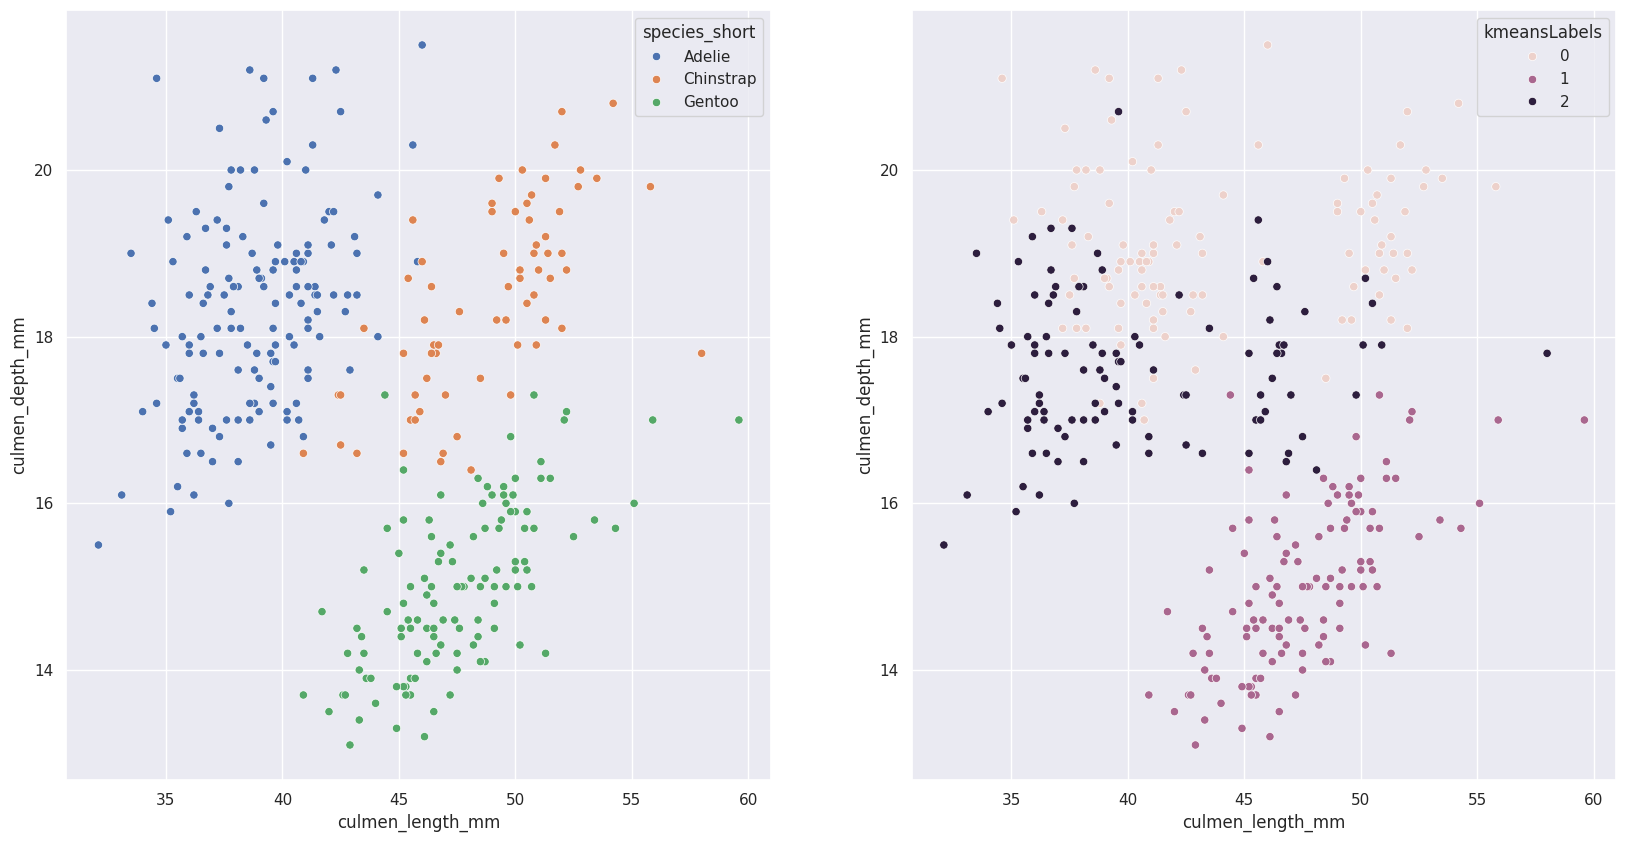

In [15]:
#create two plots side by side

fig, (ax1, ax2) = plt.subplots(ncols=2,  figsize = (20,10))
sns.scatterplot(x="culmen_length_mm", y="culmen_depth_mm", data = penguins_clean, hue = "species_short", ax=ax1)
sns.scatterplot(x="culmen_length_mm", y="culmen_depth_mm", data = penguins_clean, hue = "kmeansLabels", ax=ax2)

<Axes: xlabel='flipper_length_mm', ylabel='body_mass_g'>

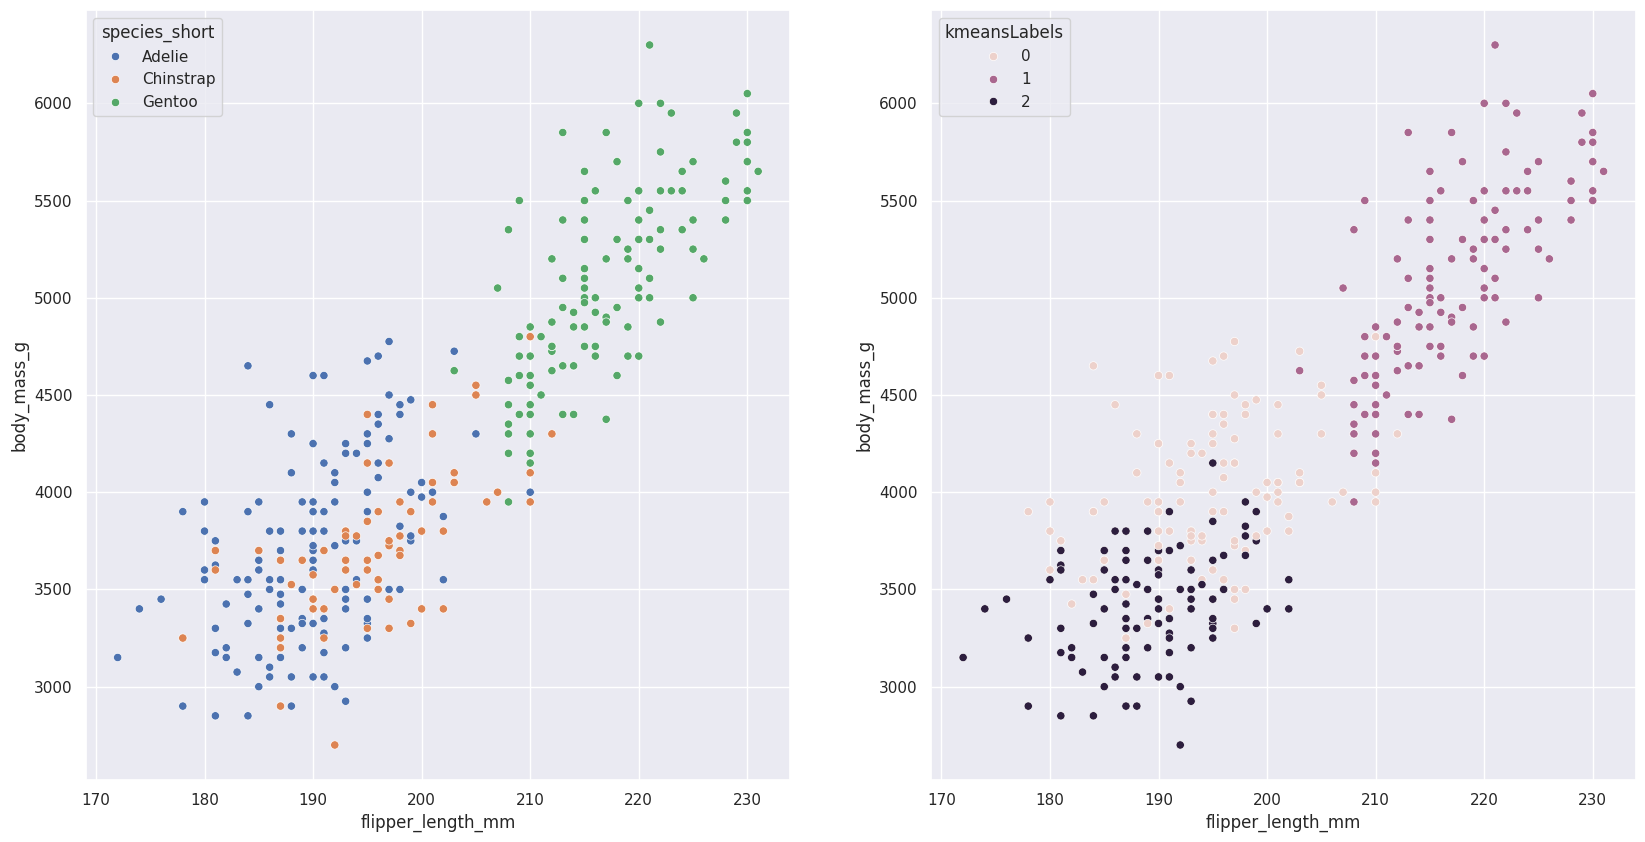

In [16]:
#create two plots side by side

fig, (ax1, ax2) = plt.subplots(ncols=2,  figsize = (20,10))
sns.scatterplot(x="flipper_length_mm", y="body_mass_g", data = penguins_clean, hue = "species_short", ax=ax1)
sns.scatterplot(x="flipper_length_mm", y="body_mass_g", data = penguins_clean, hue = "kmeansLabels", ax=ax2)

# now with only 2 variables

In [17]:
import numpy as np
X_scaled_select = X_scaled[:, [0, 2]]

In [18]:
#Train another model
model_3 = KMeans(n_clusters=3)
model_3.fit(X_scaled_select)
labels_select = model_3.predict(X_scaled_select)

In [19]:
#plotting the Cross-tab matrix with the new labels

matrix_new = pd.DataFrame({'labels': labels_select, 'species': y})
ct_new = pd.crosstab(matrix_new['labels'], matrix_new['species'])
print(ct_new)

species  Adelie  Chinstrap  Gentoo
labels                            
0             1          4     119
1           141          5       0
2             4         59       1


In [20]:
penguins_clean["kmeansLabels"] = labels_select

/tmp/ipykernel_11579/1071958234.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  penguins_clean["kmeansLabels"] = labels_select


<Axes: xlabel='culmen_length_mm', ylabel='flipper_length_mm'>

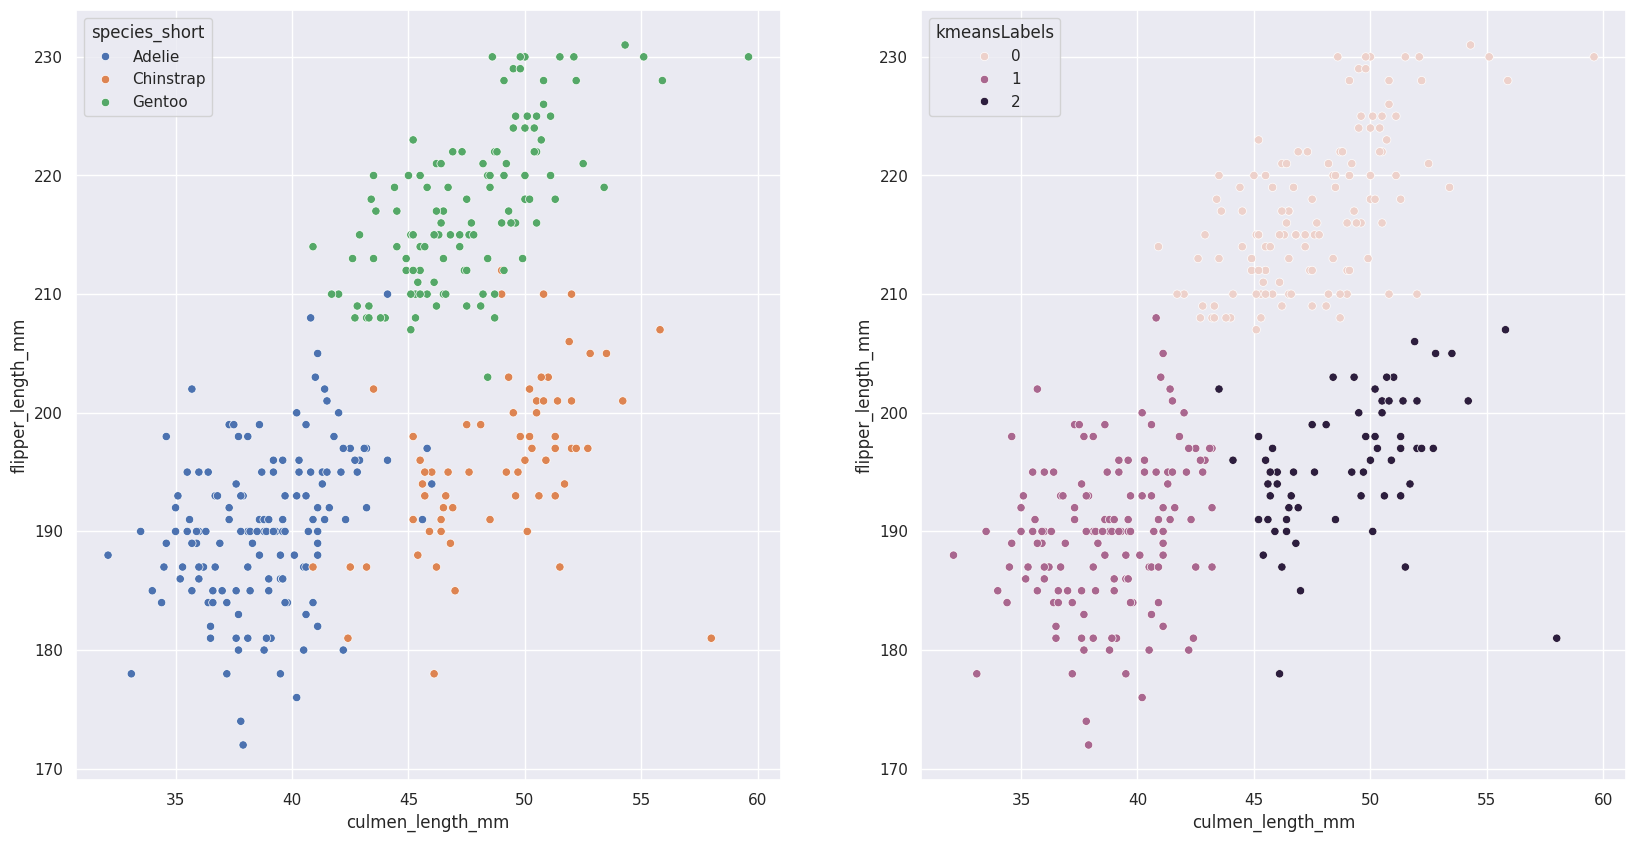

In [21]:
#create two plots side by side

fig, (ax1, ax2) = plt.subplots(ncols=2,  figsize = (20,10))
sns.scatterplot(x="culmen_length_mm", y="flipper_length_mm", data = penguins_clean, hue = "species_short", ax=ax1)
sns.scatterplot(x="culmen_length_mm", y="flipper_length_mm", data = penguins_clean, hue = "kmeansLabels", ax=ax2)